# Diabetes Prediction

Standalone classification project for estimating diabetes outcome from clinical measurements.

## Diabetes project

This notebook develops a diabetes classification pipeline from the supplied Pima-style dataset. The target is `Outcome` (0 = non-diabetic, 1 = diabetic). The project uses the tutorial workflow while making each processing decision visible and reproducible.

## 1. Imports and reproducibility

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
print('Working directory:', os.getcwd())

Working directory: e:\jupyter project\.repos\diabetes


In [3]:
# Load the dataset and define the raw feature/target columns.
diabetes = pd.read_csv('diabetes.csv')
DIABETES_FEATURES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
DIABETES_TARGET = 'Outcome'
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Shape:', diabetes.shape)
display(diabetes.head())

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 2. Data quality and target balance

The dataset has no null values, but zero is not physiologically plausible for several clinical measurements. We inspect those values before replacing them. The target balance matters because accuracy alone can hide poor detection of diabetic cases.

Missing values:


,count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Duplicate rows: 0
Zeros in candidate measurements:


,zero_count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


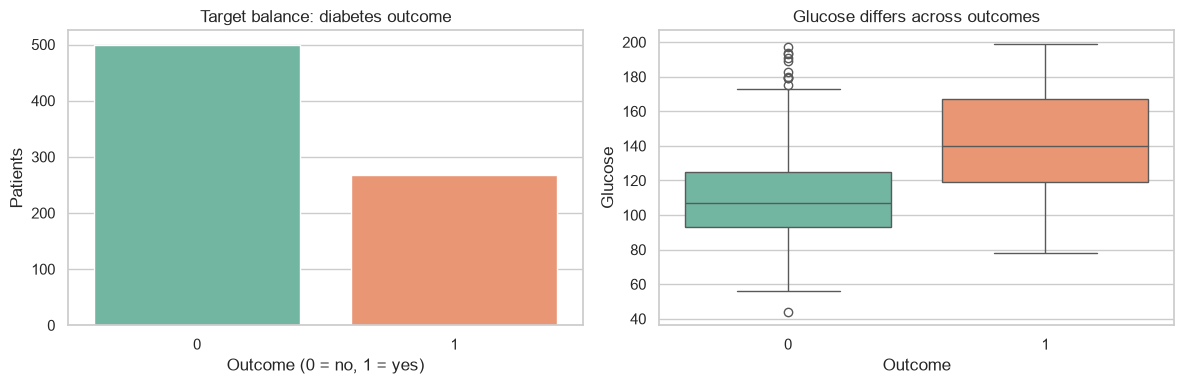

In [4]:
print('Missing values:')
display(diabetes.isna().sum().rename('count').to_frame())
print('Duplicate rows:', diabetes.duplicated().sum())
print('Zeros in candidate measurements:')
display(diabetes[zero_as_missing].eq(0).sum().rename('zero_count').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=diabetes, x='Outcome', ax=axes[0], palette='Set2')
axes[0].set_title('Target balance: diabetes outcome')
axes[0].set_xlabel('Outcome (0 = no, 1 = yes)')
axes[0].set_ylabel('Patients')
sns.boxplot(data=diabetes, x='Outcome', y='Glucose', ax=axes[1], palette='Set2')
axes[1].set_title('Glucose differs across outcomes')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Glucose')
plt.tight_layout()
plt.show()

## 3. Clinical relationships and representation

The heatmap is useful here because it shows which measured variables have stronger linear relationships with the target. It is descriptive evidence, not a replacement for model evaluation. The model representation is one row per patient and eight numeric features.

Feature matrix shape: (768, 8)
Each row is one patient; each column is one clinical feature.


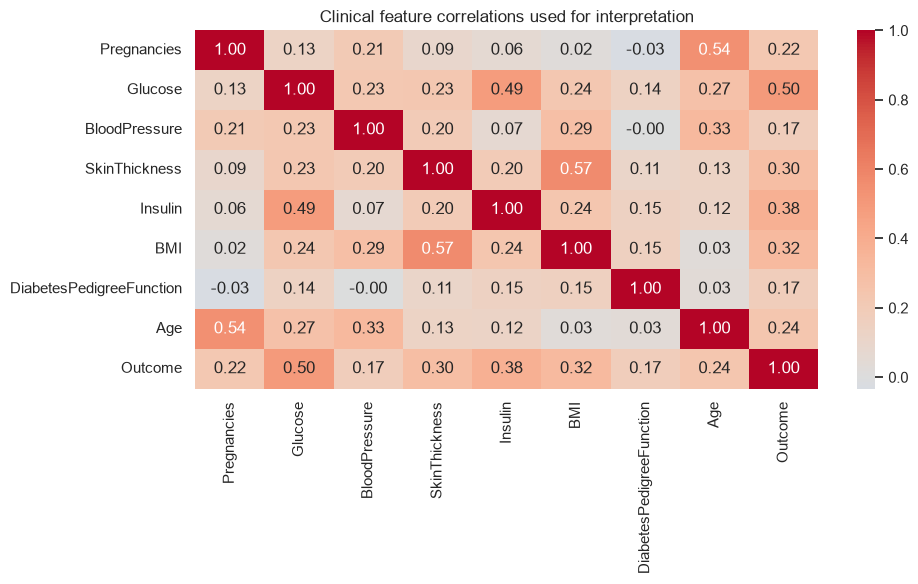

In [5]:
diabetes_model = diabetes.drop_duplicates().copy()
diabetes_model[zero_as_missing] = diabetes_model[zero_as_missing].replace(0, np.nan)
X_diabetes = diabetes_model[DIABETES_FEATURES]
y_diabetes = diabetes_model[DIABETES_TARGET]
print('Feature matrix shape:', X_diabetes.shape)
print('Each row is one patient; each column is one clinical feature.')

plt.figure(figsize=(10, 6))
sns.heatmap(diabetes_model[DIABETES_FEATURES + [DIABETES_TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Clinical feature correlations used for interpretation')
plt.tight_layout()
plt.show()

In [6]:
# Keep the test set untouched until final evaluation.
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.20, stratify=y_diabetes, random_state=RANDOM_STATE
)

diabetes_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
print('Training rows:', X_diabetes_train.shape[0])
print('Test rows:', X_diabetes_test.shape[0])

Training rows: 614
Test rows: 154


## 4. Train comparable classification models

Logistic Regression gives an interpretable linear baseline, KNN tests distance-based learning, SVM tests a margin-based boundary, and Random Forest tests nonlinear feature interactions. Every model receives the same imputed and standardized representation.

In [7]:
diabetes_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=19),
    'SVM RBF': SVC(probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
}
diabetes_pipelines = {}
for name, estimator in diabetes_models.items():
    diabetes_pipelines[name] = Pipeline([
        ('preprocessor', diabetes_preprocessor),
        ('model', estimator),
    ])
    diabetes_pipelines[name].fit(X_diabetes_train, y_diabetes_train)
print('Trained:', ', '.join(diabetes_pipelines))

Trained: Logistic Regression, KNN, SVM RBF, Random Forest


## 5. Evaluate models on unseen patients

Accuracy is useful, but recall and F1 are more informative when missing a diabetic patient is costly. We compare all models on the same untouched test set and visualize the trade-off.

,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest,0.8636,0.8235,0.7778,0.8000
SVM RBF,0.8377,0.7636,0.7778,0.7706
KNN,0.7857,0.7059,0.6667,0.6857
Logistic Regression,0.7078,0.5882,0.5556,0.5714


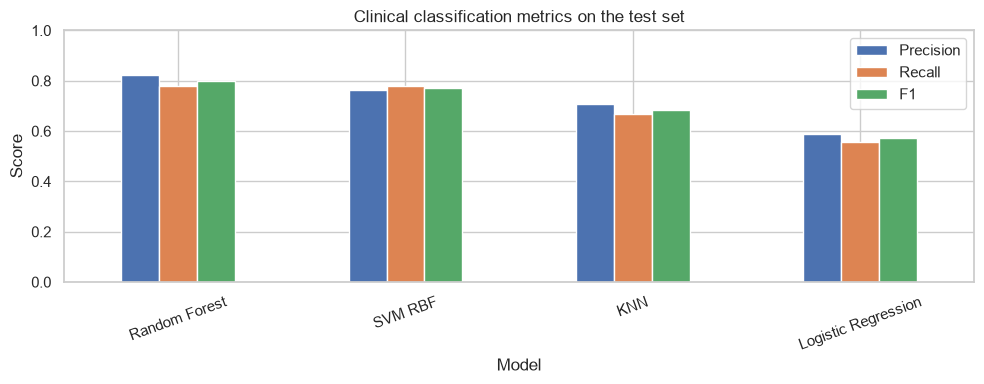

In [8]:
diabetes_rows = []
for name, pipeline in diabetes_pipelines.items():
    prediction = pipeline.predict(X_diabetes_test)
    diabetes_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_diabetes_test, prediction),
        'Precision': precision_score(y_diabetes_test, prediction, zero_division=0),
        'Recall': recall_score(y_diabetes_test, prediction, zero_division=0),
        'F1': f1_score(y_diabetes_test, prediction, zero_division=0),
    })
diabetes_results = pd.DataFrame(diabetes_rows).set_index('Model').sort_values('F1', ascending=False)
display(diabetes_results.round(4))

ax = diabetes_results[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(10, 4), ylim=(0, 1), rot=20)
ax.set_title('Clinical classification metrics on the test set')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 6. Select the model and inspect errors

Selected model by F1: Random Forest
Confusion matrix:
[[91  9]
 [12 42]]


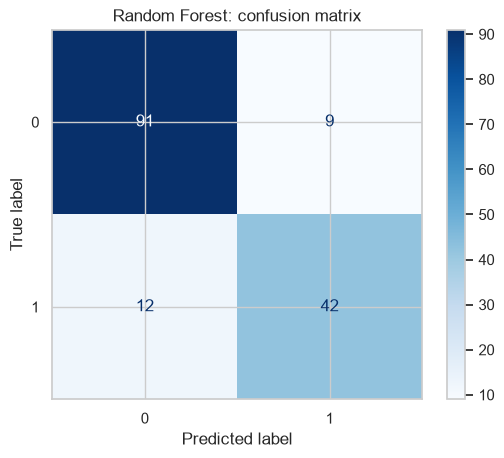

In [9]:
diabetes_best_name = diabetes_results.index[0]
diabetes_best_pipeline = diabetes_pipelines[diabetes_best_name]
diabetes_best_prediction = diabetes_best_pipeline.predict(X_diabetes_test)
print('Selected model by F1:', diabetes_best_name)
print('Confusion matrix:')
print(confusion_matrix(y_diabetes_test, diabetes_best_prediction))

ConfusionMatrixDisplay.from_predictions(y_diabetes_test, diabetes_best_prediction, cmap='Blues')
plt.title(f'{diabetes_best_name}: confusion matrix')
plt.show()

## 7. Controlled representation experiment

KNN uses distances, so feature scale can change which patients are considered neighbors. This experiment tests scaled versus unscaled features using the same train/test split.

In [10]:
knn_unscaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', KNeighborsClassifier(n_neighbors=19)),
])
knn_unscaled.fit(X_diabetes_train, y_diabetes_train)
experiment = pd.DataFrame({
    'Representation': ['Scaled features', 'Unscaled features'],
    'Accuracy': [
        accuracy_score(y_diabetes_test, diabetes_pipelines['KNN'].predict(X_diabetes_test)),
        accuracy_score(y_diabetes_test, knn_unscaled.predict(X_diabetes_test)),
    ],
})
display(experiment.round(4))

,Representation,Accuracy
0,Scaled features,0.7857
1,Unscaled features,0.8506


## 8. Persist the selected pipeline and test one new patient

In [11]:
with open('diabetes_model.sav', 'wb') as file:
    pickle.dump(diabetes_best_pipeline, file)
print('Saved diabetes_model.sav')

diabetes_sample = X_diabetes_test.iloc[[0]]
diabetes_prediction = int(diabetes_best_pipeline.predict(diabetes_sample)[0])
diabetes_probability = float(diabetes_best_pipeline.predict_proba(diabetes_sample).max())
display(diabetes_sample)
print('Prediction:', 'diabetic' if diabetes_prediction else 'non-diabetic')
print('Confidence:', round(diabetes_probability, 4))

Saved diabetes_model.sav


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64.0,27,102.5,27.4,0.294,40


Prediction: non-diabetic
Confidence: 0.844


In [10]:
diabetes_sample = X_diabetes_test.iloc[[0]]
diabetes_prediction = int(diabetes_best_pipeline.predict(diabetes_sample)[0])
diabetes_probability = None
if hasattr(diabetes_best_pipeline, 'predict_proba'):
    diabetes_probability = float(diabetes_best_pipeline.predict_proba(diabetes_sample).max())
print('Sample input:')
display(diabetes_sample)
print('Prediction:', 'diabetic' if diabetes_prediction else 'non-diabetic')
print('Confidence:', None if diabetes_probability is None else round(diabetes_probability, 4))

Sample input:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64.0,27,102.5,27.4,0.294,40


Prediction: non-diabetic
Confidence: 0.844
